# Lab 8: Statistical Models of Networks

This lab introduces **statistical approaches to modeling networks**. We will particularly focus on visualization and simulation instead of estimation of statistical models, so we can understand their properties. We will specifically cover:

- Transition from deterministic structures → random graphs → structured randomness → statistical models
- Use **null models** to evaluate network properties
- Understand the intuition behind **Exponential Random Graph Models (ERGMs)**
- Simulate networks with different structural statistics
- Perform a simple **ERGM** estimation

In [146]:
## Setup

import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
# from tqdm import tqdm

np.random.seed(123456789)

# Visualization function for graphs
def plot_graph(g, title="Network", layout_algorithm="fr"):
    _, ax = plt.subplots(figsize=(6, 6))
    ig.plot(
        g,
        target=ax,
        layout=layout_algorithm,
        vertex_size=25,
        vertex_color="indianred",
        vertex_label=list(range(g.vcount())),
        edge_width=1.5,
        bbox=(400,400),
        margin=30
    )
    ax.set_title(title)
    plt.show()


## Networks as Data Objects

In the data, we can map units and connections to:
- Nodes (actors, agents, entities)
- Edges (relationships, interactions)

We have covered many statistics that are useful to summarize an observed network:
- Number of edges
- Degree distribution
- Clustering / triangles
- Path lengths
- Centrality

We showcase the transition from deterministic to random and finally to structured random networks.

### Deterministic Network

Simple deterministic network: a ring lattice. Each node connects to its two neighbors.

IGRAPH U--- 20 20 -- 


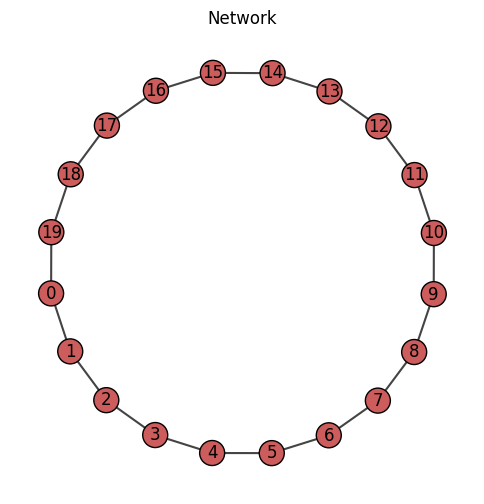

Number of edges: 20
Number of triangles: 0.0


In [158]:
n = 20
g_ring = ig.Graph.Ring(n)

print(g_ring.summary())
plot_graph(g_ring)

print("Number of edges:", g_ring.ecount())
print("Number of triangles:", sum(g_ring.transitivity_local_undirected(mode="zero")) * 1/3)

### Random Graphs

The simplest random network model is the **Erdős–Rényi graph**. Each pair of nodes connects independently with probability \(p\). This creates randomness but no higher-level structure.

IGRAPH U--- 50 607 -- 


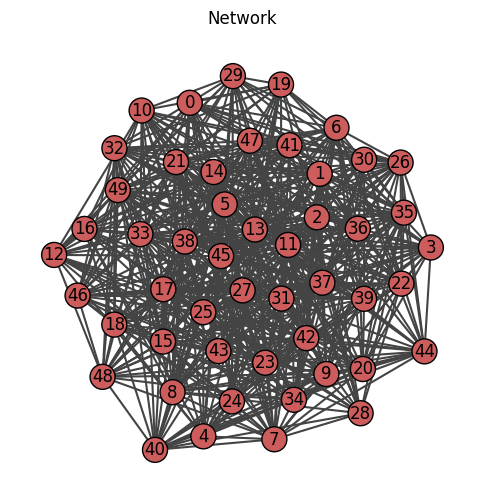

Edges: 607
Triangles: 8.332144862522675


In [165]:
n = 50
p = 0.5

g_random = ig.Graph.Erdos_Renyi(n=n, p=p)

print(g_random.summary())
plot_graph(g_random)
print("Edges:", g_random.ecount())
print("Triangles:", sum(g_random.transitivity_local_undirected(mode="zero")) * 1/3)

### Structured Randomness

We now generate a network designed to have **many triangles**. One way to do this is to create **dense communities**. Inside each community, nodes connect with high probability.
Between communities, connections are rare. This simulates a positive assortative matching setting in a Stochastic Block Model (SBM).

IGRAPH U--- 50 188 -- 


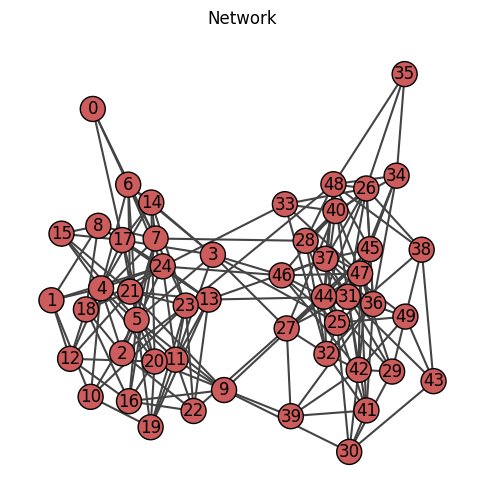

Edges in structured graph: 188
Triangles in structured graph: 4.047859547859548


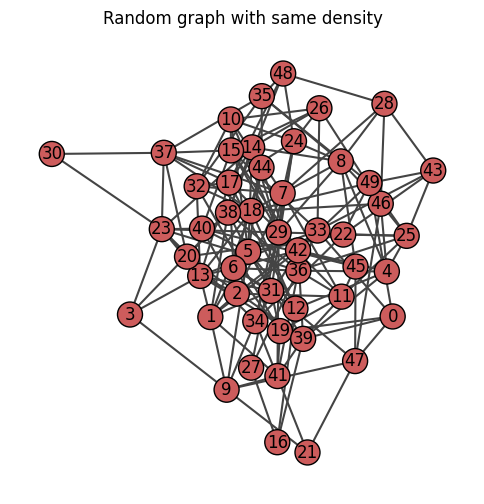

Edges in random graph: 177
Triangles in random graph: 2.594925444925445


In [179]:
sizes = [25, 25]

p_in = 0.3
p_out = 0.01

g_struct = ig.Graph.SBM(
    block_sizes=sizes,
    pref_matrix=[[p_in, p_out],
                 [p_out, p_in]],
)

print(g_struct.summary())
plot_graph(g_struct)
triangles_struct = sum(g_struct.transitivity_local_undirected(mode="zero")) * 1/3
print("Edges in structured graph:", g_struct.ecount())
print("Triangles in structured graph:", triangles_struct)

# Compare with a random graph of similar size and density.
p_match = g_struct.ecount() / (g_struct.vcount()*(g_struct.vcount()-1)/2)
g_random2 = ig.Graph.Erdos_Renyi(n=g_struct.vcount(), p=p_match)
plot_graph(g_random2, title="Random graph with same density")
triangles_rand = sum(g_random2.transitivity_local_undirected(mode="zero")) * 1/3
print("Edges in random graph:", g_random2.ecount())
print("Triangles in random graph:", triangles_rand)

## Null Models

How can we understand whether patterns we observed are random or truly meaningful?

A **null model** represents what we expect under randomness. We compare an observed network statistic against many networks generated from the null model as benchmark statistics. If the observed statistic lies far outside the distribution, we conclude it is **unlikely under randomness**.

we use the ER random graphs as null model. Simulate many random graphs and compute the number of triangles.

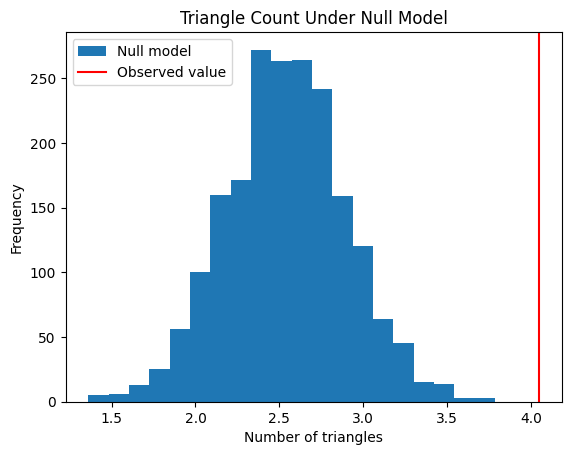

Observed triangles: 4.047859547859548
Mean under null: 2.541847548080288
Std under null: 0.3575901200922388
Z-score: 4.211559310952972
p-value: 0.0


In [180]:
n_sim = 2000
triangle_counts = []
# p_match = 0.15

for _ in range(n_sim):
    g = ig.Graph.Erdos_Renyi(n=g_struct.vcount(), p=p_match)
    t = sum(g.transitivity_local_undirected(mode="zero")) * 1/3
    triangle_counts.append(t)

triangle_counts = np.array(triangle_counts)

# Plot the distribution of triangle counts under the null model
plt.hist(triangle_counts, bins=20, label = "Null model")
plt.axvline(triangles_struct, label = "Observed value", color = 'red')
plt.title("Triangle Count Under Null Model")
plt.xlabel("Number of triangles")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print("Observed triangles:", triangles_struct)
print("Mean under null:", triangle_counts.mean())
print("Std under null:", triangle_counts.std())
print("Z-score:", (triangles_struct - triangle_counts.mean()) / triangle_counts.std())
print("p-value:", (triangle_counts >= triangles_struct).mean())


## Exponential Random Graph Models (ERGMs)

ERGMs describe networks probabilistically. As an example, one could assign probability:

\begin{equation*}
    P(\mathcal{G}; \theta) = \frac{1}{Z(\theta)} \exp(\theta_0 + \theta_1 \cdot \text{edges}(\mathcal{G}) + \theta_2 \cdot \text{triangles}(\mathcal{G}) )
\end{equation*}

Key components:

- **Network statistics** (edges, triangles, etc.)
- **Parameters** controlling their importance
- **Normalization constant** that ensures a proper probability between 0 and 1

Interpretation:
- Positive parameter → statistic encouraged
- Negative parameter → statistic discouraged

We will simulate networks with an ERGM-like mechanism. Edges are randomly added or removed. Changes are accepted depending on how they affect the ERGM probability.

In [181]:
def count_triangles(g):
    return sum(g.transitivity_local_undirected(mode="zero")) * 1/3

def ergm_simulation(n, constant, theta_edges, theta_triangles, steps=5000):

    g = ig.Graph.Erdos_Renyi(n=n, p=0.1)

    for _ in range(steps):

        i, j = np.random.choice(n, 2, replace=False)

        if g.are_adjacent(i, j):
            g.delete_edges([(i, j)])
            delta_edges = -1
        else:
            g.add_edges([(i, j)])
            delta_edges = 1

        delta_triangles = count_triangles(g)

        log_ratio = constant + theta_edges * delta_edges + theta_triangles * delta_triangles

        if np.log(np.random.rand()) > log_ratio:
            if delta_edges == 1:
                g.delete_edges([(i, j)])
            else:
                g.add_edges([(i, j)])

    return g

### Exploring Parameter Values

First consider **zero parameters**. No behaviour encouraged, which is equivalent to pure random graphs.

Edges: 110
Triangles: 0.8875661375661376


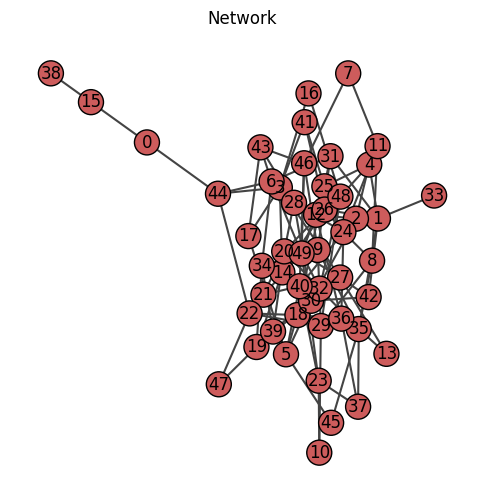

In [185]:
g0 = ergm_simulation(50, -10.0, 0, 0)

print("Edges:", g0.ecount())
print("Triangles:", count_triangles(g0))
plot_graph(g0)

Now try **positive triangle parameter**.

Edges: 28
Triangles: 0.6888888888888888


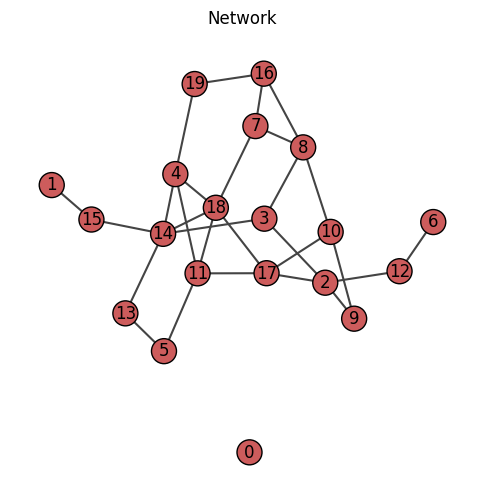

In [195]:
g_tri = ergm_simulation(20, -0.5, -2.0, -120.0)

print("Edges:", g_tri.ecount())
print("Triangles:", count_triangles(g_tri))
plot_graph(g_tri)

### Exercise for you

Try now taking some time to change the parameters:
- Positive edge parameter
- Negative triangle parameter
- Large triangle parameter

Observe how network structure changes. Discuss!

## Degeneracy in ERGMs

ERGMs sometimes behave poorly due to the large number of networks that exist and have to be placed a positive probability over. This is a difficult task and some parameter combinations lead to issues in generation / estimation. Examples:

- **No reasonable solutions** (unstable model)
- **Trivial solutions** (empty or complete graph)

Try extreme triangle parameters.

Edges: 23
Triangles: 0.8555555555555555


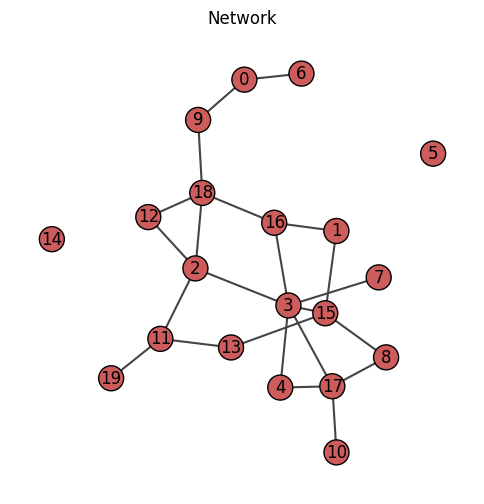

In [209]:
g_extreme = ergm_simulation(20, -200, -300.0, -800)

print("Edges:", g_extreme.ecount())
print("Triangles:", count_triangles(g_extreme))
plot_graph(g_extreme)

## Real Network Example

We now load a real-world network and understand its connection structure. We again use random graphs as a comparison in order to test whether these are truly present or just there by chance.

Load the **Zachary Karate Club network**. This network represents friendships in a university karate club. $n = 34$ members creating 78 total connections in community-like structures.

IGRAPH U--- 34 78 -- 


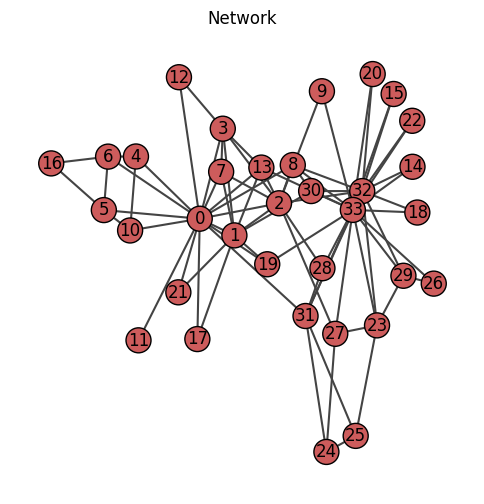

Edges: 78
Triangles: 6.467236086353733


In [155]:
g_real = ig.Graph.Famous("Zachary")

print(g_real.summary())
plot_graph(g_real)

# Compute its statistics
edges_real = g_real.ecount()
triangles_real = count_triangles(g_real)

print("Edges:", edges_real)
print("Triangles:", triangles_real)

### Simple ERGM Parameter Search

We now attempt a **very simple estimation idea**. Goal:

Find parameters that generate networks with similar statistics. If we have them, these will lead to good fit of the ERGM to data. We simulate many networks and compare statistics.

In [156]:
theta_constant_grid = np.linspace(-1, 1, 10)
theta_edges_grid = np.linspace(-2, 0, 10)
theta_tri_grid = np.linspace(0, 1, 10)


results = []
for tc in theta_constant_grid:
    for te in theta_edges_grid:
        for tt in theta_tri_grid:

            g_sim = ergm_simulation(g_real.vcount(), tc, te, tt, steps=2000)

            e = g_sim.ecount()
            t = count_triangles(g_sim)

            score = abs(e - edges_real) + abs(t - triangles_real)

            results.append((te, tt, score))

# Find the best parameter combination.
best = sorted(results, key=lambda x: x[2])[0]
print("Best results:", best)


Best results: (np.float64(-1.7777777777777777), np.float64(0.1111111111111111), 4.878347197464844)


Edges: 93
Triangles: 1.316931216931217


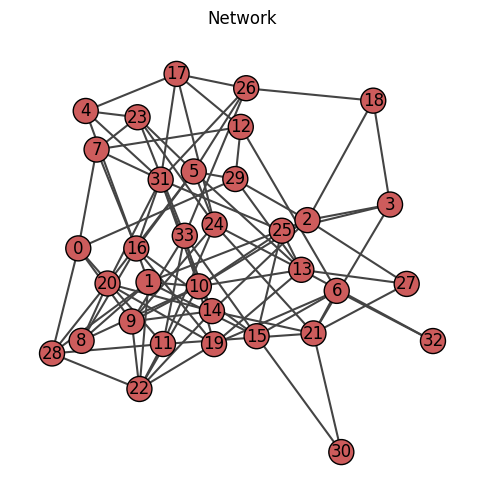

In [157]:

# Simulate a network using the estimated parameters.
g_est = ergm_simulation(g_real.vcount(), 0, best[0], best[1], steps=5000)

print("Edges:", g_est.ecount())
print("Triangles:", count_triangles(g_est))

plot_graph(g_est)

## Interpretation and Limitations

Statistical network models allow us to:

- Test whether structures are **statistically unusual**
- Model networks using interpretable statistics
- Simulate networks with specific structural features

However, ERGMs have limitations:

- Estimation can be computationally difficult
- Models may become **degenerate**
- Results depend heavily on chosen statistics

Choosing the right statistics is therefore crucial.

## Exercises

Try the following:

1. Change ERGM parameters and observe resulting networks.
2. Add additional statistics (for example degree-related ones).
3. Test whether the karate club network has unusually many triangles relative to a random graph with the same density.
4. Create your own structured network and test it against a null model.